# 1. Orientação ao motorista: antecipar consumo elevado

**Pergunta:** sensores atuais e dos últimos 10 s antecipam uma média de consumo alta nos próximos 10 s?
**Tipo:** classificação supervisionada de um evento operacional definido por regra, não de severidade.
**Aplicação:** estudar se um alerta antecipado oferece informação além do consumo atual. Não prescreve manobras nem demonstra economia.

O alvo é a média de `Taccm(t+1), ..., Taccm(t+10)` acima do percentil 75 calculado **somente nos ensaios de treino**. O limite muda por fold; reportamos cada ensaio separadamente. O teste é sempre um ensaio inteiro não usado no ajuste. Janelas-alvo de 10 s não se sobrepõem. O histórico de entrada inclui somente t−9 a t. O conjunto de atributos inclui `Tau`, comandos, consumo atual e os Pi atuais `Pi_6_log10` e `Pi_8`; `Pi_4` foi excluído por conter tempo decorrido.

Execute todas as células. [Documento das aplicações](../APLICACOES_PREVISAO_CONSUMO.md).

**Limite dos Pi:** `Pi_6` também contém tempo decorrido (`Temp²` no denominador). A exclusão de `Pi_4` não elimina esse efeito. O modelo mantém `Pi_6` para explorar os dados disponíveis; testar sua remoção é uma análise futura, não realizada aqui.

In [1]:
from pathlib import Path
import sys, json, hashlib, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display, Markdown
get_ipython().run_line_magic("matplotlib", "inline")
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "Motor/Dados/Data_set.CSV").is_file())
sys.path.insert(0, str(ROOT / "Motor/notebooks"))
from consumo_utils import load_data, forecast_frame, regressor
OUT = ROOT / "Motor/resultados_consumo/01_orientacao_motorista"
OUT.mkdir(parents=True, exist_ok=True)
dados = load_data(ROOT)
manifest = {
    "python": platform.python_version(), "pandas": pd.__version__,
    "numpy": np.__version__, "scikit_learn": sklearn.__version__,
    "seed": 42, "unidade": "U = unidade numérica de Taccm; unidade física não confirmada",
    "sha256": {name: hashlib.sha256((ROOT / "Motor/Dados" / name).read_bytes()).hexdigest()
               for name in ["Data_set.CSV", "Data_set_param.CSV", "Dataset_Modelagem_Pi.csv"]},
}
(OUT / "ambiente.json").write_text(json.dumps(manifest, indent=2, ensure_ascii=False))
print("Amostras por ensaio:", dados.groupby("Experimento").size().to_dict())
print("Unidades: taxa em U; integral em U·s. Sem conversão automática para litros.")

Amostras por ensaio: {'D1T1A': 1984, 'D1T1B': 1776, 'D1T2': 3876, 'D2T1': 1703}
Unidades: taxa em U; integral em U·s. Sem conversão automática para litros.


In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import precision_score, recall_score, f1_score, balanced_accuracy_score, roc_auc_score
frame, features = forecast_frame(dados, horizon=10, history=10, stride=10)
assert (frame.target_start > frame.Temp).all()
display(frame.groupby("Experimento").size().rename("janelas"))

Experimento
D1T1A    197
D1T1B    176
D1T2     386
D2T1     169
Name: janelas, dtype: int64

## Treinar e comparar com uma regra de persistência

Referência: emitir alerta se a taxa **atual** já supera o mesmo limite do treino.
Modelo: Random Forest com parâmetros fixos e limiar de probabilidade 0,5. Não otimizamos limiar no teste.
Precisão indica a fração de alertas que se confirmam; recall indica a fração dos eventos futuros que foram antecipados. F1 equilibra ambos, sem garantir utilidade ao motorista.

In [3]:
metrics, predictions = [], []
for experiment in sorted(frame.Experimento.unique()):
    train = frame[frame.Experimento != experiment]
    test = frame[frame.Experimento == experiment]
    threshold = train.fuel_future_mean.quantile(.75)
    y_train = (train.fuel_future_mean > threshold).astype(int)
    y_test = (test.fuel_future_mean > threshold).astype(int)
    model = make_pipeline(
        SimpleImputer(strategy="median", add_indicator=True),
        RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_leaf=8,
                               class_weight="balanced", random_state=42, n_jobs=1),
    )
    model.fit(train[features], y_train)
    probability = model.predict_proba(test[features])[:, 1]
    alert = probability >= .5
    persistence = test.cur_Taccm.to_numpy() > threshold
    for name, decision, score in [("modelo", alert, probability),
                                  ("persistencia", persistence, test.cur_Taccm.to_numpy())]:
        metrics.append(dict(ensaio=experiment, metodo=name, n=len(test), limiar_U=threshold,
                            eventos=int(y_test.sum()), alertas=int(np.sum(decision)),
                            precisao=precision_score(y_test,decision,zero_division=0),
                            recall=recall_score(y_test,decision,zero_division=0),
                            f1=f1_score(y_test,decision,zero_division=0),
                            acuracia_balanceada=balanced_accuracy_score(y_test,decision),
                            auc=roc_auc_score(y_test,score) if y_test.nunique()==2 else np.nan))
    rows=test[["Experimento","Temp","target_start","target_end","cur_Acc","cur_Tau",
               "cur_Taccm","fuel_future_mean"]].copy()
    rows["limiar_U"]=threshold; rows["probabilidade"]=probability
    rows["alerta"]=alert; rows["evento_real"]=y_test.to_numpy()
    predictions.append(rows)
metrics=pd.DataFrame(metrics)
predictions=pd.concat(predictions,ignore_index=True)
metrics.to_csv(OUT/"metricas.csv",index=False)
predictions.to_csv(OUT/"previsoes.csv",index=False)
display(metrics.round(3))

,ensaio,metodo,n,limiar_U,eventos,alertas,precisao,recall,f1,acuracia_balanceada,auc
0,D1T1A,modelo,197,16.510,49,64,0.625,0.816,0.708,0.827,0.867
1,D1T1A,persistencia,197,16.510,49,53,0.679,0.735,0.706,0.810,0.851
2,D1T1B,modelo,176,16.461,47,49,0.735,0.766,0.750,0.833,0.891
3,D1T1B,persistencia,176,16.461,47,40,0.750,0.638,0.690,0.780,0.881
4,D1T2,modelo,386,17.204,83,124,0.581,0.867,0.696,0.848,0.925
5,D1T2,persistencia,386,17.204,83,85,0.729,0.747,0.738,0.836,0.910
6,D2T1,modelo,169,16.168,51,71,0.662,0.922,0.770,0.859,0.898
7,D2T1,persistencia,169,16.168,51,54,0.741,0.784,0.762,0.833,0.898


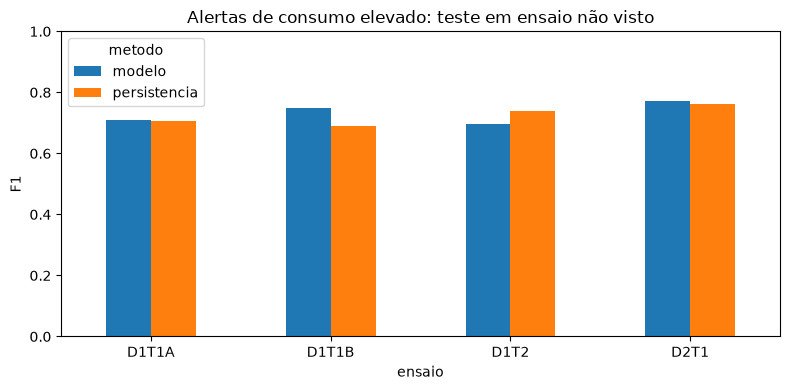

,Experimento,Temp,target_start,target_end,cur_Acc,cur_Tau,cur_Taccm,fuel_future_mean,limiar_U,probabilidade,alerta,evento_real
19,D1T1A,200.0,201.0,210.0,82.4,1168.0,42.05,43.785,16.510,0.954,True,1
75,D1T1A,760.0,761.0,770.0,100.0,1296.0,42.90,14.355,16.510,0.954,True,0
29,D1T1A,300.0,301.0,310.0,82.4,1248.0,46.95,41.200,16.510,0.953,True,1
176,D1T1A,1770.0,1771.0,1780.0,100.0,1520.0,44.65,38.815,16.510,0.953,True,1
238,D1T1B,420.0,421.0,430.0,93.6,1312.0,42.15,18.625,16.461,0.951,True,1
93,D1T1A,940.0,941.0,950.0,82.4,1328.0,44.40,37.180,16.510,0.950,True,1
28,D1T1A,290.0,291.0,300.0,80.0,992.0,34.55,36.120,16.510,0.949,True,1
752,D1T2,3799.0,3800.0,3809.0,84.0,1376.0,41.60,31.450,17.204,0.948,True,1


O modelo superou a referência em **3/4 ensaios** em F1. São alertas de consumo relativo elevado, não recomendações validadas de condução nem falhas.

In [4]:
fig,ax=plt.subplots(figsize=(8,4))
metrics.pivot(index="ensaio",columns="metodo",values="f1").plot.bar(ax=ax)
ax.set(ylabel="F1",title="Alertas de consumo elevado: teste em ensaio não visto",ylim=(0,1))
ax.tick_params(axis="x",rotation=0)
fig.tight_layout(); fig.savefig(OUT/"f1_por_ensaio.png",dpi=150); plt.show()
display(predictions.sort_values("probabilidade",ascending=False).head(8).round(3))
comparison=metrics.pivot(index="ensaio",columns="metodo",values="f1")
wins=int((comparison.modelo > comparison.persistencia).sum())
display(Markdown(f"O modelo superou a referência em **{wins}/4 ensaios** em F1. "
    "São alertas de consumo relativo elevado, não recomendações validadas de condução nem falhas."))

## Limites e próximo passo

Não há rótulos de direção econômica nem experimento mostrando que responder ao alerta economiza combustível. A classificação usa um limite estatístico; demanda de torque, trânsito e segurança podem justificar consumo alto. Compare falsos positivos e eventos perdidos com quem conhece as coletas antes de desenhar uma interface para o motorista. O horizonte depende dos comandos futuros ainda desconhecidos.

## Melhorias aplicadas: seleção de limiar e agrupamento de avisos

Mantemos um ensaio externo intocado. Nos outros três, cada um é usado como validação interna uma vez, com treino nos dois restantes. O percentil 75 que define o evento é calculado apenas no treino de cada divisão. As probabilidades internas escolhem o limiar na grade 0,30–0,85 (passo 0,05), minimizando falsos positivos por minuto sujeito a recall macro >= 0,75. Essa meta é exploratória e pode ser revista conforme os critérios de avaliação; se não for alcançável, escolhemos o maior recall e registramos a inviabilidade.

Comparamos persistência, limiar fixo 0,5 e limiar escolhido. **Um aviso por sequência consecutiva de decisões positivas**, não um aviso por janela. Um aviso é falso se nenhuma de suas janelas se confirmar. Episódios reais são sequências de janelas com média futura elevada; não rótulos de falha. Registramos recall por janela e por episódio.

A antecedência é relativa à **confirmação da primeira janela de 10 s do episódio**: fim da primeira janela menos instante do aviso agrupado que se sobrepõe ao episódio. Também reportamos a antecedência da primeira decisão correta. Um aviso que começou com janelas falsas pode ter antecedência maior que o horizonte; isso mede sua idade, não demonstra previsão correta com horizonte maior. Pode ser zero ou negativa quando há atraso. Não é o tempo até o início físico de um pico; esse início não está rotulado.

In [5]:
NEW=OUT/"melhorias"
NEW.mkdir(exist_ok=True)
new_manifest=dict(manifest)
new_manifest["codigo_sha256"]={name:hashlib.sha256((ROOT/"Motor/notebooks"/name).read_bytes()).hexdigest()
                              for name in ["consumo_utils.py","consumo_melhorias.py"]}
(NEW/"ambiente.json").write_text(json.dumps(new_manifest,indent=2,ensure_ascii=False))

696

In [6]:
from consumo_melhorias import run_alerts
improved=run_alerts(dados)
for name,table in improved.items():table.to_csv(NEW/f"{name}.csv",index=False)
display(improved["selecao"].round(3))
display(improved["metricas"].round(3))
display(improved["contextos"].query("metodo == 'limiar_ajustado'").round(3))

Alertas: teste D1T1A


Alertas: teste D1T1B


Alertas: teste D1T2


Alertas: teste D2T1


,ensaio,limiar,meta_viavel,limite_U,treino
0,D1T1A,0.65,True,16.510,"D1T1B,D1T2,D2T1"
1,D1T1B,0.60,True,16.461,"D1T1A,D1T2,D2T1"
2,D1T2,0.65,True,17.204,"D1T1A,D1T1B,D2T1"
3,D2T1,0.60,True,16.168,"D1T1A,D1T1B,D1T2"


,ensaio,metodo,n,limiar,precisao,recall,f1,fp,fn,fp_min,avisos,avisos_falsos,avisos_falsos_min,episodios_reais,episodios_detectados,recall_episodios,antecedencia_confirmacao_mediana_s,antecedencia_decisao_correta_mediana_s,decisoes_positivas
0,D1T1A,persistencia,197,NaN,0.679,0.735,0.706,17,13,0.518,24,8,0.244,19,16,0.842,0.0,0.0,53
1,D1T1A,limiar_050,197,0.50,0.625,0.816,0.708,24,9,0.731,28,11,0.335,19,17,0.895,10.0,10.0,64
2,D1T1A,limiar_ajustado,197,0.65,0.667,0.735,0.699,18,13,0.548,26,9,0.274,19,16,0.842,5.0,5.0,54
3,D1T1B,persistencia,176,NaN,0.750,0.638,0.690,10,17,0.341,18,6,0.205,16,11,0.688,0.0,0.0,40
4,D1T1B,limiar_050,176,0.50,0.735,0.766,0.750,13,11,0.443,21,7,0.239,16,13,0.812,0.0,0.0,49
5,D1T1B,limiar_ajustado,176,0.60,0.729,0.745,0.737,13,12,0.443,22,7,0.239,16,13,0.812,0.0,0.0,48
6,D1T2,persistencia,386,NaN,0.729,0.747,0.738,23,21,0.358,41,10,0.155,38,30,0.789,10.0,10.0,85
7,D1T2,limiar_050,386,0.50,0.581,0.867,0.696,52,11,0.808,55,24,0.373,38,32,0.842,10.0,10.0,124
8,D1T2,limiar_ajustado,386,0.65,0.663,0.807,0.728,34,16,0.528,46,17,0.264,38,30,0.789,10.0,10.0,101
9,D2T1,persistencia,169,NaN,0.741,0.784,0.762,14,11,0.497,20,3,0.107,18,15,0.833,10.0,10.0,54


,ensaio,metodo,contexto,n,fp,fn,tp
5,D1T1A,limiar_ajustado,demanda_alta,34,11,0,23
6,D1T1A,limiar_ajustado,freio_fora_faixa,52,4,4,9
7,D1T1A,limiar_ajustado,frenagem,35,0,1,0
8,D1T1A,limiar_ajustado,movimento,50,3,5,4
9,D1T1A,limiar_ajustado,parado,26,0,3,0
20,D1T1B,limiar_ajustado,demanda_alta,31,8,0,23
21,D1T1B,limiar_ajustado,freio_fora_faixa,26,1,1,7
22,D1T1B,limiar_ajustado,frenagem,39,0,2,0
23,D1T1B,limiar_ajustado,movimento,52,4,9,5
24,D1T1B,limiar_ajustado,parado,28,0,0,0


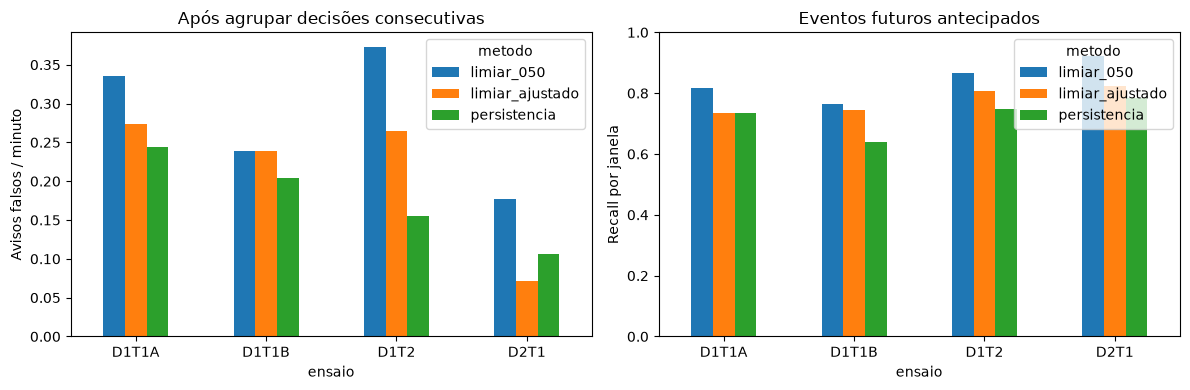

O ajuste reduziu avisos falsos por minuto em **3/4 ensaios** contra o limiar 0,5. A seleção interna não garante a mesma meta de recall no ensaio externo. O quadro por contexto separa freio >100% como leitura fora da faixa, não como frenagem legítima.

In [7]:
fig,axes=plt.subplots(1,2,figsize=(12,4))
improved["metricas"].pivot(index="ensaio",columns="metodo",values="avisos_falsos_min").plot.bar(ax=axes[0])
axes[0].set(ylabel="Avisos falsos / minuto",title="Após agrupar decisões consecutivas")
improved["metricas"].pivot(index="ensaio",columns="metodo",values="recall").plot.bar(ax=axes[1])
axes[1].set(ylabel="Recall por janela",title="Eventos futuros antecipados",ylim=(0,1))
for ax in axes:ax.tick_params(axis="x",rotation=0)
fig.tight_layout();fig.savefig(NEW/"alertas_ajustados.png",dpi=150);plt.show()
summary=improved["metricas"].pivot(index="ensaio",columns="metodo",values="avisos_falsos_min")
wins=int((summary.limiar_ajustado<summary.limiar_050).sum())
display(Markdown(f"O ajuste reduziu avisos falsos por minuto em **{wins}/4 ensaios** contra o limiar 0,5. "
                "A seleção interna não garante a mesma meta de recall no ensaio externo. "
                "O quadro por contexto separa freio >100% como leitura fora da faixa, não como frenagem legítima."))